Fig. 2D 

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(devtools)
    library(showtext)
    library(sysfonts)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
    
})


In [3]:
#if start from here
WD <- "data/"
sample <- "filtered_count_crRNA1_crRNA4.rds"
set.seed(100) 

adata <- readRDS(paste0(WD, sample))
adata

An object of class Seurat 
33861 features across 182 samples within 1 assay 
Active assay: RNA (33861 features, 0 variable features)
 1 layer present: counts

In [4]:
#remove PIK3CA gene because its expression is likely affected by additional primers.
x <- c('PIK3CA')
adata <- subset(adata,features=setdiff(rownames(adata),x))
adata

An object of class Seurat 
33860 features across 182 samples within 1 assay 
Active assay: RNA (33860 features, 0 variable features)
 1 layer present: counts

In [5]:
adata <- NormalizeData(adata)

Normalizing layer: counts



Finding variable features for layer counts

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.284”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.50104”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1.1033e-15”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.090619”
When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“ggrepel: 13 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


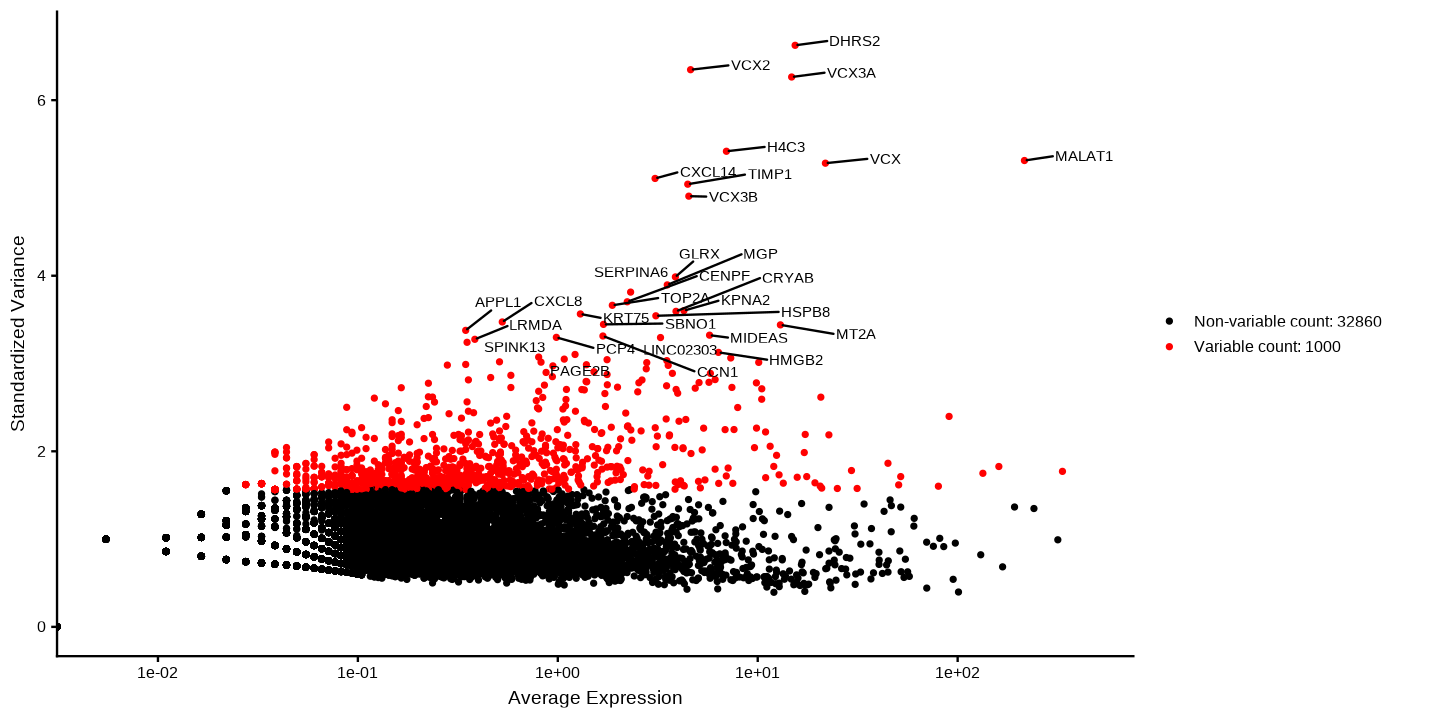

In [6]:
options(repr.plot.width = 12, repr.plot.height =6) 
adata <- FindVariableFeatures(adata, selection.method = "vst", nfeatures = 1000)

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(adata), 30)

# plot variable features with and without labels
plot1 <- VariableFeaturePlot(adata)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot2

In [7]:
adata <- ScaleData(adata)
adata <- RunPCA(adata, features = VariableFeatures(object = adata))

Centering and scaling data matrix

PC_ 1 
Positive:  KRT19, GAGE1, VCX, GAGE2A, DSCAM-AS1, AGR2, VCX3A, CLIC3, GSTM3, CD24 
	   KRT8, EDN1, LINC02303, VAMP8, KRT18, VCX3B, XAGE2, MGP, ENSG00000254337, PGR 
	   LINC00992, VCX2, SERPINA6, SPTSSB, STC2, CYP1B1, AGR3, HSPB8, HSP90AA1, YIF1A 
Negative:  VIM, EGR1, DHRS2, MIR4435-2HG, AXL, GSTP1, SPARC, ANXA2, EMP1, MAGEA4 
	   ITGB1, GAPDH, TIMP1, IFITM3, PRAME, DUXAP10, IL18, FTL, MIDEAS, ANXA5 
	   NNMT, TPM4, NASP, HAPLN1, GPRC5A, MT2A, MT1E, NF2, OCIAD2, VMP1 
PC_ 2 
Positive:  MT-ND5, MT-CYB, MT-ND2, MT-ND1, MT-CO1, MTND2P28, MT-ATP6, MT-ND4L, MT-ND4, MT-ATP8 
	   MTCO1P12, MT-RNR1, MT-ND3, MALAT1, RPN2, NEAT1, PSAP, CLU, LDLR, ARL6IP1 
	   MIR23AHG, DST, CENPF, CHD4, LGALS3BP, GOLGB1, HSP90AA1, ANKRD20A8P, PXDN, CTSB 
Negative:  TMSB10, RPS27L, H1-2, SEM1, OCIAD2, FTL, GLRX, GSTP1, SRI, POLR2J 
	   SUN3, PAGE2, GAPDH, MT1E, SFTA1P, TMSB15A, CRYAB, TNNC1, ANXA2, KRT81 
	   TPI1, MT2A, TXNRD2, RPS4X, SUB1, ENSG00000290032, H2BC12, ID3, 

In [8]:
# Examine and visualize PCA results a few different ways
print(adata[["pca"]], dims = 1:5, nfeatures = 5)

PC_ 1 
Positive:  KRT19, GAGE1, VCX, GAGE2A, DSCAM-AS1 
Negative:  VIM, EGR1, DHRS2, MIR4435-2HG, AXL 
PC_ 2 
Positive:  MT-ND5, MT-CYB, MT-ND2, MT-ND1, MT-CO1 
Negative:  TMSB10, RPS27L, H1-2, SEM1, OCIAD2 
PC_ 3 
Positive:  NDC80, UBE2C, TOP2A, KPNA2, BUB1 
Negative:  NEAT1, LINC01297, RENBP, ARID5B, LOXL4 
PC_ 4 
Positive:  ENO1, H2BC12, TUBA1B, TUBA1C, TXNRD2 
Negative:  UBE2D1, R3HCC1L, EHHADH, SYT14, TRPM7 
PC_ 5 
Positive:  CEP55, LINC01560, DSN1, ENSG00000290105, SMC3 
Negative:  NSUN7, KIF20A, STAG2, ARRDC4, SHOX2 


In [9]:
adata <- FindNeighbors(adata, dims = 1:20, reduction = "pca")
adata <- FindClusters(adata, resolution = 2, cluster.name = "unintegrated_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 182
Number of edges: 5254

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.3841
Number of communities: 5
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
22:59:42 UMAP embedding parameters a = 0.583 b = 1.334

22:59:42 Read 182 rows and found 10 numeric columns

22:59:42 Using Annoy for neighbor search, n_neighbors = 18

22:59:42 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

22:59:43 Writing NN index file to temp file /tmp/RtmpgO2YWE/file2c8cf618f94184

22:59:43 Searching Annoy index using 1 thread, search_k = 1800

22:59:43 Annoy recall = 100%

22:59:43 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

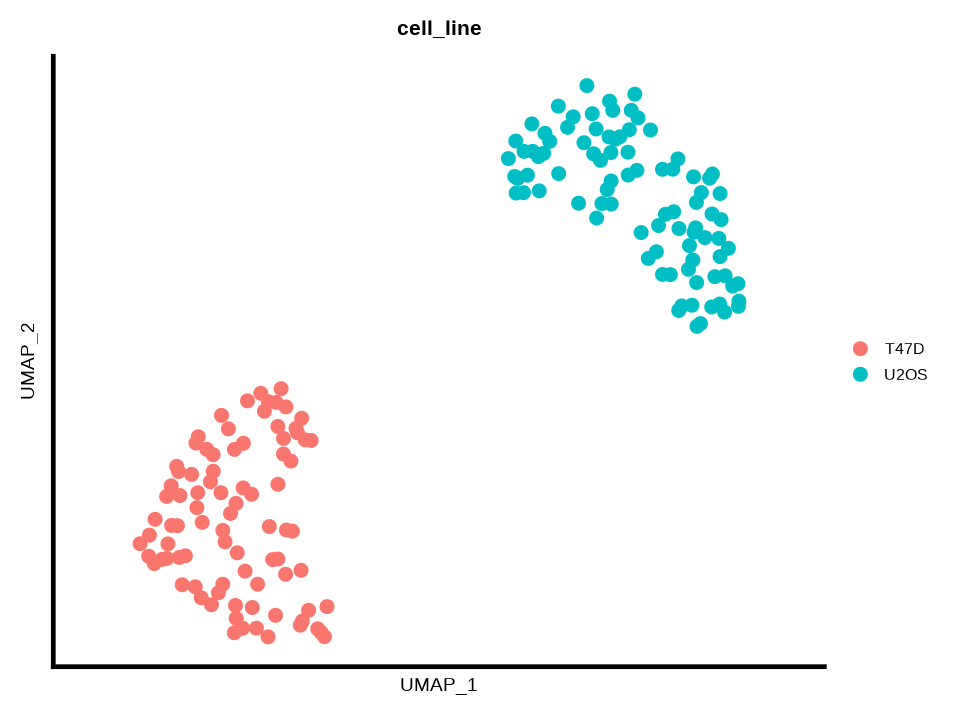

In [10]:
options(repr.plot.width = 8, repr.plot.height =6) 

adata <- RunUMAP(adata, dims = 1:10, reduction = "pca", reduction.name = "UMAP", n.neighbors=18, min.dist=0.5) 
# visualize by batch and cell type annotation

p = DimPlot(adata, reduction = "UMAP", group.by = c("cell_line"), pt.size=3) +
     theme(legend.text=element_text(size=9.5)) +
     theme(axis.line=element_line(size=1)) +
     xlim(-12,12) +
     ylim(-5,5) +
     theme(axis.text.x=element_blank()) +
     theme(axis.text.y=element_blank()) +
     theme(axis.ticks.x=element_blank()) +
     theme(axis.ticks.y=element_blank()) +
      theme(
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12)
  )
p

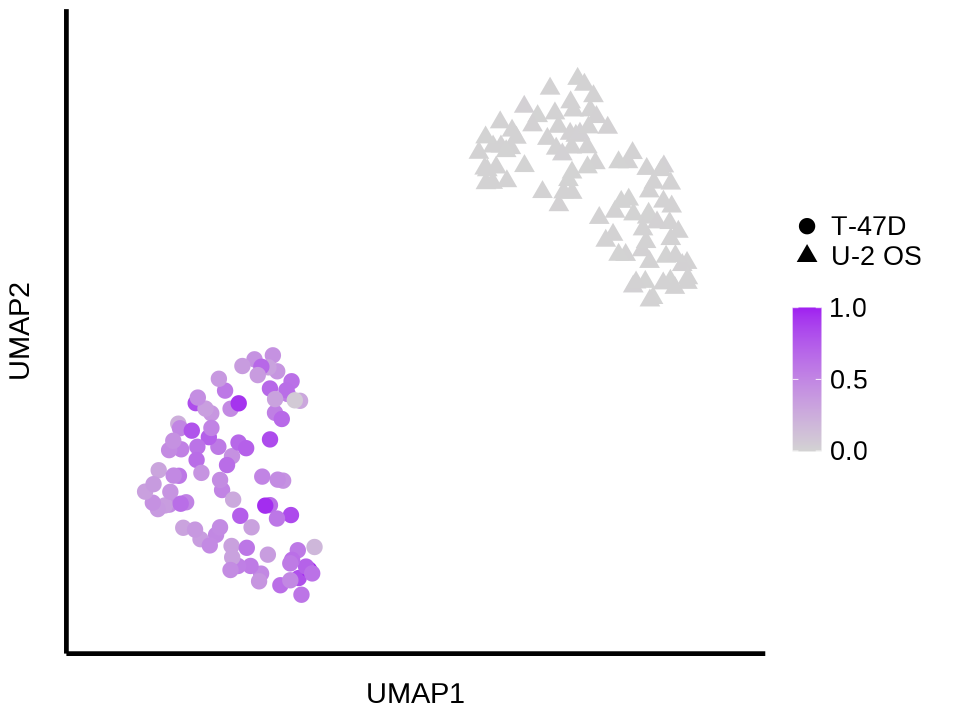

In [11]:
options(repr.plot.width = 8, repr.plot.height =6) 
df <- Embeddings(adata, "UMAP") %>% as.data.frame()
df$group <- adata@meta.data$cell_line
df$Cas12a_relative <- adata@meta.data$Cas12a_relative

ggplot(df, aes(UMAP_1, UMAP_2, shape = group, color = Cas12a_relative)) +
  geom_point(size = 4) +
  scale_shape_manual(values = c(16, 17), labels = c(
      "T47D" = "T-47D",
      "U2OS"  = "U-2 OS")) +
  scale_color_gradient(low = "light gray", high = "purple", breaks = c(0, 0.5, 1)) +
  labs(x = "UMAP1", y = "UMAP2") +
  xlim(-12,12) +
  ylim(-6,6) +
  theme_minimal() +
  theme(
    axis.line = element_line(size = 1, color = "black"),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20, color = "black"),
    legend.title = element_blank(),
    axis.title.x = element_text(size = 22, margin = margin(t = 15), color = "black"), 
    axis.title.y = element_text(size = 22, margin = margin(r = 15), color = "black"),
    
  )

In [12]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] future_1.67.0      showtext_0.9-7     showtextdb_3.0     sysfonts_0.8.9    
 [5] devtools_2.4.5     usethis_3.1.0      dplyr_1.1.4        Seurat_5.3.0      
 [9] SeuratObject_5.2.0 sp_2.2-0           ggplot2_3.5.2     

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_2.0.0 